# Homework 9.1 - Теория



1.   Основная идея метода главных компонент заключается в:

    a)	Отборе m самых важных признаков согласно критерию максимизации дисперсии.

    b)	Выкидывании каждого признака по отдельности, пока качество модели не вырастет.

    c)	Удалении неинформативных признаков, веса которых зануляются при l1-регуляризации.

    d)	Нахождении m новых признаков, которые линейно выражаются через исходные.



Ваш Ответ: D

2.  Метод главных компонент подбирает веса для новых признаков решая задачу:

    a)	Максимизации дисперсии объектов в изначальном признаковом пространстве.

    b)	Максимизации дисперсии объектов в новом признаковом пространстве.

    c)	Минимизации дисперсии объектов в изначальном признаковом пространстве.

    d)	Минимизации дисперсии объектов в новом признаковом пространстве.
    



Ваш Ответ: B?

3. Метод главных компонент НЕ используется для задачи:

    a)	Извлечения новых признаков из старых путем максимизации дисперсии.

    b)	Проецирования данных из многомерного признакового пространства для визуализации данных.

    c)	Предсказания целевой переменной: вектор, максимизирующий дисперсию исходных признаков, является хорошим предсказанием модели.
    
    d)	Выделение нескольких наиболее информативных признаков для ускорения обучения моделей.

Ваш Ответ: C

4. Главное отличие t-SNE от PCA заключается в том, что:

    a) t-SNE генерирует более информативные признаки.

    b) В отличие от PCA, в t-SNE новые признаки имеют квадратичную зависимость от старых признаков.

    c) t-SNE обычно обучается быстрее PCA.
    
    d) Позволяет изображать даже сложные данные.

Ваш Ответ: D

5. Почему важно центрировать данные перед применением PCA?


Ваш Ответ: Оптимизация дисперсии. Без центрирования по среднему первый главный компонент, найденный PCA, может соответствовать среднему значению данных вместо направления максимальной дисперсии, а суть PCA как раз таки в максимизации дисперсии.

6. Что означает параметр "перплексия" в t-SNE, и как он влияет на результат?


Ваш Ответ: t-SNE это нелинейный метод извлечения признака, perplexity это гиперпараметр в t-SNE и она определяет, сколько соседей учитываются в расчете условных вероятностей сходства. Большая перплексия приводит к усреднению вероятностей и созданию более глобальной структуры, в то время как маленькая перплексия подчеркивает локальную структуру.

# Homework 9.2 - Практика

## Dataset
Вы будете работать с данными агрегатора такси [Sigma Cabs](https://www.kaggle.com/datasets/arashnic/taxi-pricing-with-mobility-analytics).

Описание признаков:

1. **Trip_ID**: ID for TRIP
2. **Trip_Distance**: The distance for the trip requested by the customer
3. **TypeofCab**: Category of the cab requested by the customer
4. **CustomerSinceMonths**: Customer using cab services since n months; 0 month means current month
5. **LifeStyleIndex**: Proprietary index created by Sigma Cabs showing lifestyle of the customer based on their behaviour
6. **ConfidenceLifeStyle_Index**: Category showing confidence on the index mentioned above
7. **Destination_Type**: Sigma Cabs divides any destination in one of the 14 categories.
8. **Customer_Rating**: Average of life time ratings of the customer till date
9. **CancellationLast1Month**: Number of trips cancelled by the customer in last 1 month
10. **Var1**, **Var2** and **Var3**: Continuous variables masked by the company. Can be used for modelling purposes
11. **Gender**: Gender of the customer

**SurgePricingType**: Target (can be of 3 types)


## Data Processing


**Задание 1.** Заполните пропуски в вещественных признаках медианой, а в категориальных - самым популярным классом.

In [115]:
# Ваш код:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("sigma_cabs.csv")

data.head(n = 10)

,Trip_ID,Trip_Distance,Type_of_Cab,Customer_Since_Months,Life_Style_Index,Confidence_Life_Style_Index,Destination_Type,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Gender,Surge_Pricing_Type
0,T0005689460,6.77,B,1.0,2.42769,A,A,3.90500,0,40.0,46,60,Female,2
1,T0005689461,29.47,B,10.0,2.78245,B,A,3.45000,0,38.0,56,78,Male,2
2,T0005689464,41.58,NaN,10.0,NaN,NaN,E,3.50125,2,NaN,56,77,Male,2
3,T0005689465,61.56,C,10.0,NaN,NaN,A,3.45375,0,NaN,52,74,Male,3
4,T0005689467,54.95,C,10.0,3.03453,B,A,3.40250,4,51.0,49,102,Male,2
5,T0005689469,19.06,E,10.0,NaN,NaN,A,2.59750,1,72.0,63,91,Male,3
6,T0005689470,29.72,E,10.0,2.83958,C,B,2.97500,1,83.0,50,75,Male,2
7,T0005689472,18.44,B,2.0,2.81871,B,A,3.58250,0,103.0,46,63,Male,2
8,T0005689473,106.80,C,3.0,NaN,NaN,A,3.14625,0,NaN,58,92,Male,2
9,T0005689474,107.19,D,5.0,3.04467,B,A,2.44375,1,NaN,58,83,Male,3


In [117]:
data.describe()

,Trip_Distance,Customer_Since_Months,Life_Style_Index,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Surge_Pricing_Type
count,131662.000000,125742.000000,111469.000000,131662.000000,131662.000000,60632.000000,131662.000000,131662.000000,131662.000000
mean,44.200909,6.016661,2.802064,2.849458,0.782838,64.202698,51.202800,75.099019,2.155747
std,25.522882,3.626887,0.225796,0.980675,1.037559,21.820447,4.986142,11.578278,0.738164
min,0.310000,0.000000,1.596380,0.001250,0.000000,30.000000,40.000000,52.000000,1.000000
25%,24.580000,3.000000,2.654730,2.152500,0.000000,46.000000,48.000000,67.000000,2.000000
50%,38.200000,6.000000,2.798050,2.895000,0.000000,61.000000,50.000000,74.000000,2.000000
75%,60.730000,10.000000,2.946780,3.582500,1.000000,80.000000,54.000000,82.000000,3.000000
max,109.230000,10.000000,4.875110,5.000000,8.000000,210.000000,124.000000,206.000000,3.000000


In [119]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131662 entries, 0 to 131661
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Trip_ID                      131662 non-null  object 
 1   Trip_Distance                131662 non-null  float64
 2   Type_of_Cab                  111452 non-null  object 
 3   Customer_Since_Months        125742 non-null  float64
 4   Life_Style_Index             111469 non-null  float64
 5   Confidence_Life_Style_Index  111469 non-null  object 
 6   Destination_Type             131662 non-null  object 
 7   Customer_Rating              131662 non-null  float64
 8   Cancellation_Last_1Month     131662 non-null  int64  
 9   Var1                         60632 non-null   float64
 10  Var2                         131662 non-null  int64  
 11  Var3                         131662 non-null  int64  
 12  Gender                       131662 non-null  object 
 13 

In [121]:
data.isnull().sum()

Trip_ID                            0
Trip_Distance                      0
Type_of_Cab                    20210
Customer_Since_Months           5920
Life_Style_Index               20193
Confidence_Life_Style_Index    20193
Destination_Type                   0
Customer_Rating                    0
Cancellation_Last_1Month           0
Var1                           71030
Var2                               0
Var3                               0
Gender                             0
Surge_Pricing_Type                 0
dtype: int64

In [123]:
categorical_features = [c for c in data.columns if data[c].dtypes == 'object']
numerical_features = [c for c in data.columns if c not in categorical_features]

categorical_features

['Trip_ID',
 'Type_of_Cab',
 'Confidence_Life_Style_Index',
 'Destination_Type',
 'Gender']

In [125]:
numerical_features

['Trip_Distance',
 'Customer_Since_Months',
 'Life_Style_Index',
 'Customer_Rating',
 'Cancellation_Last_1Month',
 'Var1',
 'Var2',
 'Var3',
 'Surge_Pricing_Type']

In [127]:
# for categorical features create function that finds most popular class and puts it into null vals
# object dtype doesn't mean that data is categorical, 
# but in our dataset it's clear that these feature are categorical except Trip_ID, that's why we drop it before replacing:

In [129]:
data.Trip_ID.nunique() 

131662

In [131]:
categorical_features = categorical_features[1:]
categorical_features

['Type_of_Cab', 'Confidence_Life_Style_Index', 'Destination_Type', 'Gender']

In [133]:
for feature in categorical_features:
    most_popular_class = data[feature].value_counts().idxmax()
    data.fillna({feature: most_popular_class}, inplace=True)

for feature in numerical_features:
    median_value = data[feature].median()
    data.fillna({feature: median_value}, inplace=True)

print(f'Categorical features popular classes: \n{data[categorical_features].value_counts().head()}')
print('\n')
print(f'Numerical features median values: \n{data[numerical_features].value_counts().head()}')

Categorical features popular classes: 
Type_of_Cab  Confidence_Life_Style_Index  Destination_Type  Gender
B            B                            A                 Male      9634
             A                            A                 Male      6022
C            B                            A                 Male      5964
B            C                            A                 Male      5746
D            B                            A                 Male      4120
Name: count, dtype: int64


Numerical features median values: 
Trip_Distance  Customer_Since_Months  Life_Style_Index  Customer_Rating  Cancellation_Last_1Month  Var1  Var2  Var3  Surge_Pricing_Type
0.31           7.0                    2.77123           2.22875          0                         61.0  49    76    1                     1
51.42          0.0                    2.88835           3.74250          3                         95.0  47    83    2                     1
51.36          10.0                   

**Задание 2.** Так как в сумме уникальных значений различных категориальных признаков окажется не супер-много, примените `One-Hot-Encoding` для них. Не забудьте в методе `pd.get_dummies` указать параметр `drop_first=True`.

In [136]:
# Ваш код:
data_encoded = data.copy()
data_encoded = pd.get_dummies(data_encoded, columns = categorical_features, drop_first=True)
data_encoded.columns

Index(['Trip_ID', 'Trip_Distance', 'Customer_Since_Months', 'Life_Style_Index',
       'Customer_Rating', 'Cancellation_Last_1Month', 'Var1', 'Var2', 'Var3',
       'Surge_Pricing_Type', 'Type_of_Cab_B', 'Type_of_Cab_C', 'Type_of_Cab_D',
       'Type_of_Cab_E', 'Confidence_Life_Style_Index_B',
       'Confidence_Life_Style_Index_C', 'Destination_Type_B',
       'Destination_Type_C', 'Destination_Type_D', 'Destination_Type_E',
       'Destination_Type_F', 'Destination_Type_G', 'Destination_Type_H',
       'Destination_Type_I', 'Destination_Type_J', 'Destination_Type_K',
       'Destination_Type_L', 'Destination_Type_M', 'Destination_Type_N',
       'Gender_Male'],
      dtype='object')

In [138]:
data_encoded.head(n = 3)

,Trip_ID,Trip_Distance,Customer_Since_Months,Life_Style_Index,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,Var3,Surge_Pricing_Type,...,Destination_Type_F,Destination_Type_G,Destination_Type_H,Destination_Type_I,Destination_Type_J,Destination_Type_K,Destination_Type_L,Destination_Type_M,Destination_Type_N,Gender_Male
0,T0005689460,6.77,1.0,2.42769,3.90500,0,40.0,46,60,2,...,False,False,False,False,False,False,False,False,False,False
1,T0005689461,29.47,10.0,2.78245,3.45000,0,38.0,56,78,2,...,False,False,False,False,False,False,False,False,False,True
2,T0005689464,41.58,10.0,2.79805,3.50125,2,61.0,56,77,2,...,False,False,False,False,False,False,False,False,False,True


## Principal component analysis (PCA)

**Задание 3.** Спроецируйте данные на двумерную плоскость, используя `PCA`. Другими словами, выделите первые две главные компоненты и изобразите данные в осях этих компонент. Не забудьте центрировать признаки перед применением метода.

**Вопрос:** Какую долю изначальной дисперсии (информации) содержат/объясняют в себе обе компоненты? Для этого воспользуйтесь атрибутом `explained_variance_ratio_` у PCA-класса.

In [142]:
# Ваш код:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [144]:
# Шаг 1: делим данные на матрицу данных X и таргет Y

X = data_encoded.drop(columns = ['Trip_ID', 'Surge_Pricing_Type'])

Y = data_encoded['Surge_Pricing_Type']

In [146]:
# Шаг 2: Центрирование данных
scaler = StandardScaler()
X_centered = scaler.fit_transform(X)

In [148]:
# берем только первые 100 значений для визуцализации чтобы не нагружать график
X = X.values
X_100 = X[:100]
X_100

array([[6.77, 1.0, 2.42769, ..., False, False, False],
       [29.47, 10.0, 2.78245, ..., False, False, True],
       [41.58, 10.0, 2.79805, ..., False, False, True],
       ...,
       [33.51, 8.0, 3.13281, ..., False, False, True],
       [66.59, 10.0, 2.85882, ..., False, False, True],
       [92.34, 10.0, 2.86489, ..., False, False, True]], dtype=object)

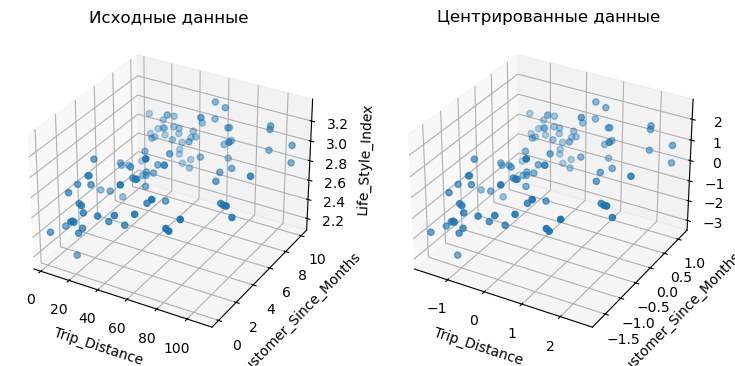

In [150]:
# --- Визуализация шага 2 ---
# Scatter plot до и после центрирования берем только первые три признака чтобы посмотреть визуализацию

X_centered_100 = X_centered[:100]

fig = plt.figure(figsize=(9, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_100[:, 0], X_100[:, 1], X_100[:, 2])
ax1.set_xlabel('Trip_Distance')
ax1.set_ylabel('Customer_Since_Months')
ax1.set_zlabel('Life_Style_Index')
ax1.set_title('Исходные данные')

ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_centered_100[:, 0], X_centered_100[:, 1], X_centered_100[:, 2])
ax2.set_xlabel('Trip_Distance')
ax2.set_ylabel('Customer_Since_Months')
ax2.set_zlabel('Life_Style_Index')
ax2.set_title('Центрированные данные')
plt.show()

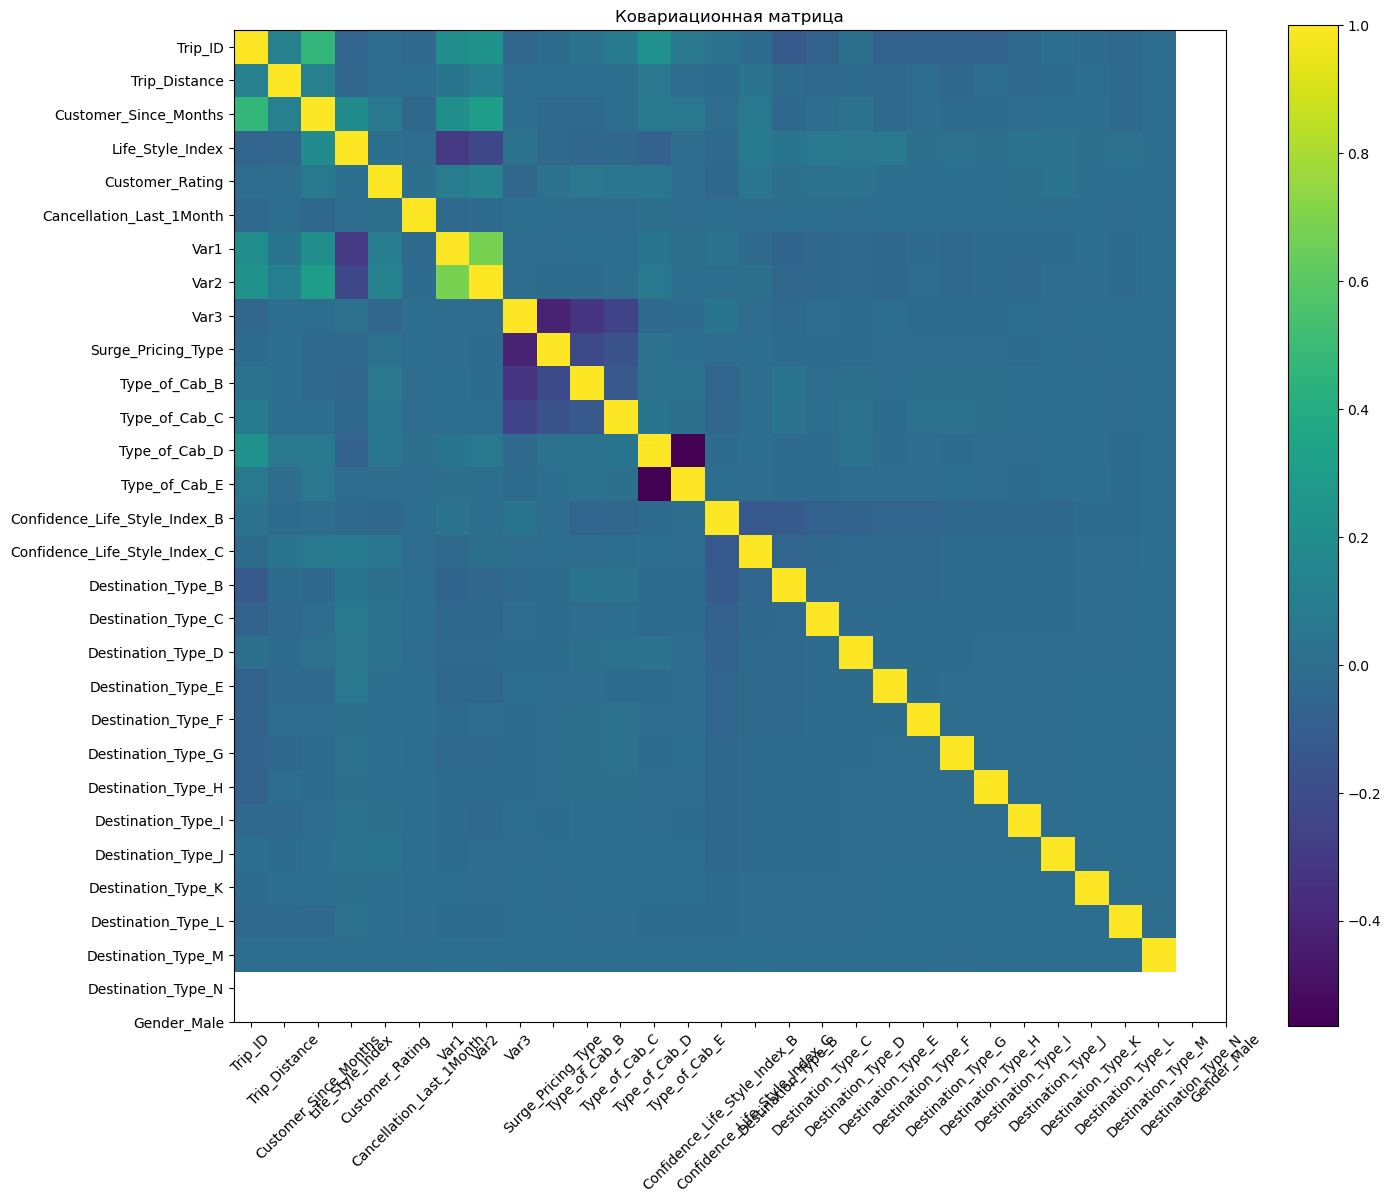

In [152]:
cov_matrix = np.cov(X_centered.T)

# --- Визуализация шага 3 ---
# Heatmap ковариационной матрицы
plt.figure(figsize=(16, 13))
plt.imshow(cov_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(data_encoded.columns)), data_encoded.columns, rotation=45)
plt.yticks(range(len(data_encoded.columns)), data_encoded.columns)
plt.title('Ковариационная матрица')
plt.show()

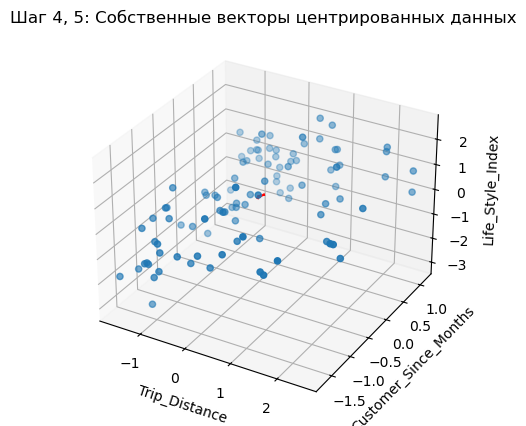

In [154]:
# Шаг 4: Нахождение собственных векторов и собственных значений
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Шаг 5: Сортировка собственных векторов
idx = eigenvalues.argsort()[::-1]   
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:,idx]

# --- Визуализация шага 4 и 5 ---
# Scatter plot с собственными векторами
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_centered_100[:, 0], X_centered_100[:, 1], X_centered_100[:, 2])

ax.set_xlabel('Trip_Distance')
ax.set_ylabel('Customer_Since_Months')
ax.set_zlabel('Life_Style_Index')

# Отображение собственных векторов
for i in range(len(eigenvectors)):
    ax.quiver(0, 0, 0, eigenvectors[0, i], eigenvectors[1, i], eigenvectors[2, i], length=eigenvalues[i]/10, color='r')
plt.title('Шаг 4, 5: Собственные векторы центрированных данных')
plt.show()

In [156]:
# Applying PCA
pca = PCA(n_components=2)  #  2 dimensions
principal_components = pca.fit_transform(X_centered)

# Create a DataFrame for principal components
principal_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])
final_df = pd.concat([principal_df, data_encoded], axis=1)

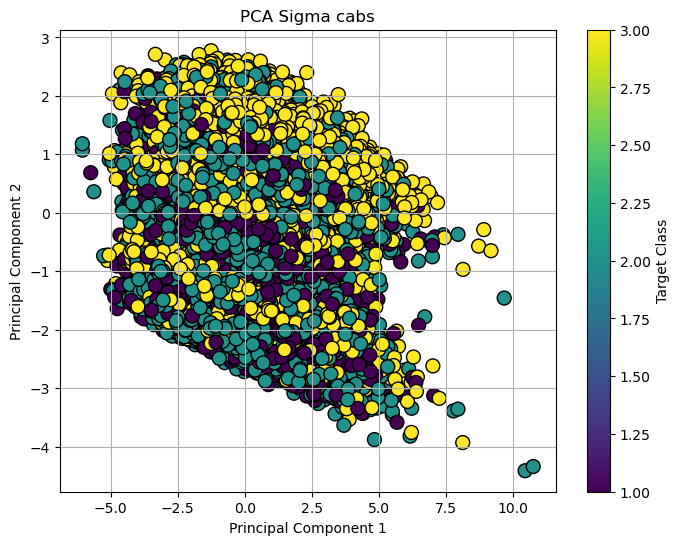

In [158]:
# Изображаем в осях

plt.figure(figsize=(8, 6))
scatter = plt.scatter(final_df['Principal Component 1'], final_df['Principal Component 2'], c=final_df['Surge_Pricing_Type'], cmap='viridis', edgecolor = 'k', s=100)
plt.title('PCA Sigma cabs')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label = 'Target Class')
plt.grid()
plt.show()

In [160]:
explained_variance_ratio = pca.explained_variance_ratio_
total_explained_variance = np.sum(explained_variance_ratio)
variance_first_two_components = np.sum(explained_variance_ratio[:2])

print(f"Explained variance of two components: {explained_variance_ratio}")
print(f"Explained variance by the first two components: {variance_first_two_components:.2f}")
print(f"Proportion of total variance explained: {variance_first_two_components / total_explained_variance:.2f}")

Explained variance of two components: [0.08054067 0.05622614]
Explained variance by the first two components: 0.14
Proportion of total variance explained: 1.00


Ответ: Первые два главных компонента объясняют следующие пропорции дисперсии в наборе данных:

Первый компонент: 8% дисперсии.
Второй компонент: 5,6% дисперсии.

**Задание 4.** Изобразите heatmap корреляции изначальных признаков с новыми двумя главными компонентами. \

**Вопрос:** Какие признаки коррелируют с первой компонентой? Какие со второй?

In [164]:
final_df.columns

Index(['Principal Component 1', 'Principal Component 2', 'Trip_ID',
       'Trip_Distance', 'Customer_Since_Months', 'Life_Style_Index',
       'Customer_Rating', 'Cancellation_Last_1Month', 'Var1', 'Var2', 'Var3',
       'Surge_Pricing_Type', 'Type_of_Cab_B', 'Type_of_Cab_C', 'Type_of_Cab_D',
       'Type_of_Cab_E', 'Confidence_Life_Style_Index_B',
       'Confidence_Life_Style_Index_C', 'Destination_Type_B',
       'Destination_Type_C', 'Destination_Type_D', 'Destination_Type_E',
       'Destination_Type_F', 'Destination_Type_G', 'Destination_Type_H',
       'Destination_Type_I', 'Destination_Type_J', 'Destination_Type_K',
       'Destination_Type_L', 'Destination_Type_M', 'Destination_Type_N',
       'Gender_Male'],
      dtype='object')

In [166]:
final_df.head()

,Principal Component 1,Principal Component 2,Trip_ID,Trip_Distance,Customer_Since_Months,Life_Style_Index,Customer_Rating,Cancellation_Last_1Month,Var1,Var2,...,Destination_Type_F,Destination_Type_G,Destination_Type_H,Destination_Type_I,Destination_Type_J,Destination_Type_K,Destination_Type_L,Destination_Type_M,Destination_Type_N,Gender_Male
0,-3.168966,-0.291227,T0005689460,6.77,1.0,2.42769,3.90500,0,40.0,46,...,False,False,False,False,False,False,False,False,False,False
1,0.564770,0.505259,T0005689461,29.47,10.0,2.78245,3.45000,0,38.0,56,...,False,False,False,False,False,False,False,False,False,True
2,0.406986,0.812164,T0005689464,41.58,10.0,2.79805,3.50125,2,61.0,56,...,False,False,False,False,False,False,False,False,False,True
3,0.539764,1.468425,T0005689465,61.56,10.0,2.79805,3.45375,0,61.0,52,...,False,False,False,False,False,False,False,False,False,True
4,2.322120,1.347351,T0005689467,54.95,10.0,3.03453,3.40250,4,51.0,49,...,False,False,False,False,False,False,False,False,False,True


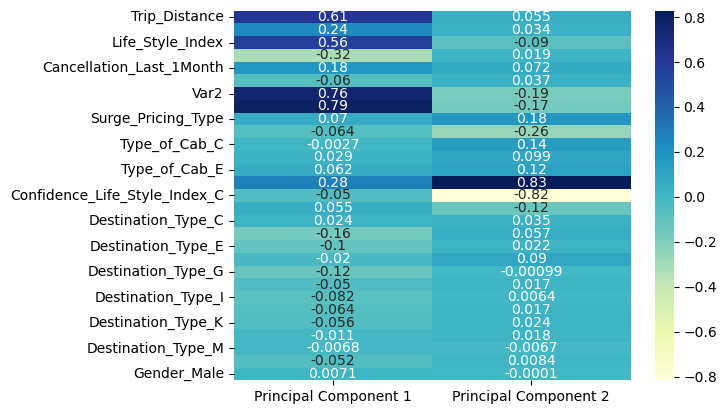

<Figure size 1800x1600 with 0 Axes>

In [168]:
# Ваш код:

#correlation matrix
final_df_without_id = final_df.drop(columns = ['Trip_ID'])
data_encoded_without_id = data_encoded.drop(columns = ['Trip_ID'])
correlation_matrix = final_df_without_id.corr()
relevant_corr = correlation_matrix.loc[data_encoded_without_id.columns, ['Principal Component 1', 'Principal Component 2']]
dataplot = sns.heatmap(relevant_corr, cmap="YlGnBu", annot=True)
plt.figure(figsize=(18, 16))
plt.show()

Ответ: 
C первой компонентой коррелируются Var2(Непрерывная переменная, скрытая компанией) = 0.76, таргет Surge_Pricing_Type = 0.79, и 
Trip_Distance(Расстояние поездки, запрошенное клиентом) = 0.61 
и слабая корреляция есть c Life_Style_Index(Запатентованный индекс, 
созданный Sigma Cabs, отображающий образ жизни клиента на основе его поведения) = 0.56

Со второй компонентой коррелируются Type_Cab_E(категория кабины E, запрошенная заказчиком) = 0.83, 
Confidence_Life_Style_Index_C (Категория, показывающая уверенность в Life_Style_Index) = -0.82 
Если брать по модулю ∣r∣ используется, чтобы сравнивать вклад признаков в компоненту, не обращая внимания на то, положительная это связь или отрицательная

**Задание 5.** Изобразите двумерную проекцию данных с метками классов. Выделите третью главную компоненту и аналогично нарисуйте трехмерную проекцию с метками классов. \

**Вопрос:** Какие признаки коррелируют с третьей компонентой?

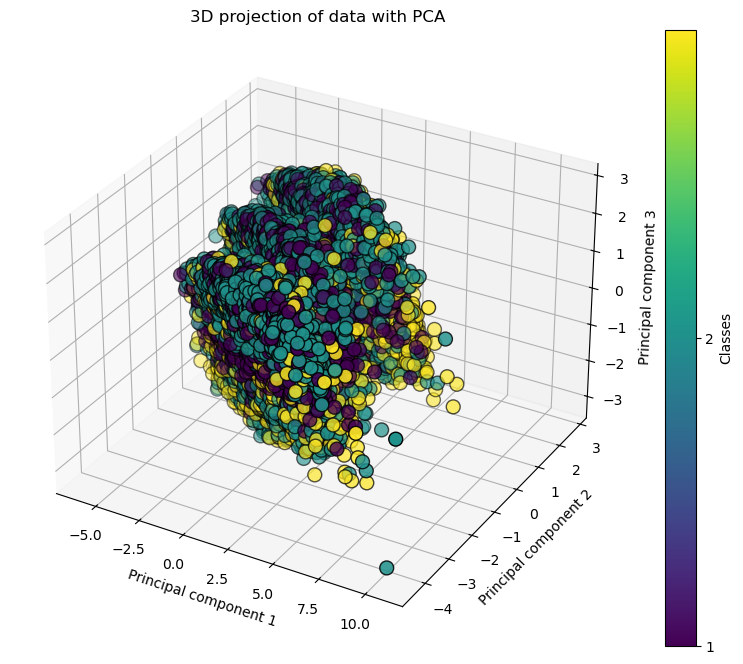

In [172]:
# Ваш код: Трехмерная проекция
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components = 3)
X_pca_3d = pca_3d.fit_transform(X_centered)

fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111, projection = '3d')
scatter_3d = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c = Y, cmap = 'viridis', edgecolor = 'k', s=100)
ax.set_title('3D projection of data with PCA')
ax.set_xlabel('Principal component 1')
ax.set_ylabel('Principal component 2')
ax.set_zlabel('Principal component 3')
fig.colorbar(scatter_3d, ticks=[0, 1, 2], label='Classes')
plt.show()


In [174]:
X_pca_3d

array([[-3.16896561, -0.29122682,  1.23039731],
       [ 0.56477009,  0.50525911,  1.67168761],
       [ 0.40698584,  0.81216387,  1.48103702],
       ...,
       [ 0.21034148,  1.46941532, -0.5854937 ],
       [ 0.53926432, -1.03070778,  1.83885785],
       [ 0.51255647, -0.2829905 , -0.2777659 ]])

In [176]:
final_df[['Principal Component 1', 'Principal Component 2' ]].head()

,Principal Component 1,Principal Component 2
0,-3.168966,-0.291227
1,0.564770,0.505259
2,0.406986,0.812164
3,0.539764,1.468425
4,2.322120,1.347351


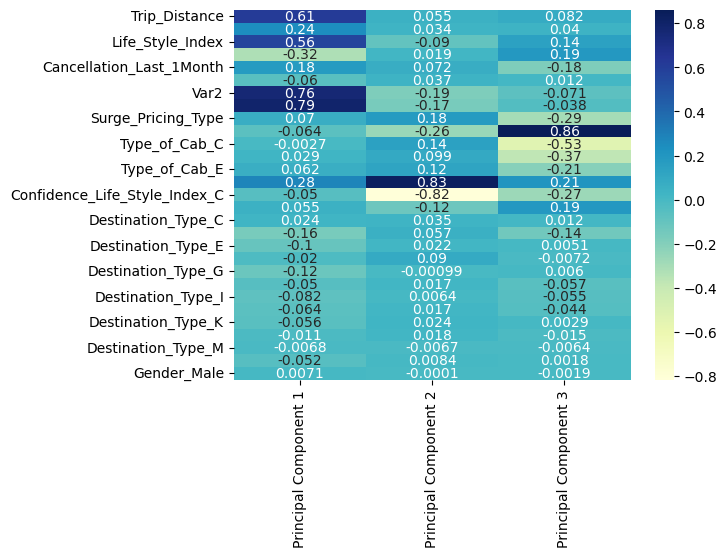

<Figure size 1800x1600 with 0 Axes>

In [178]:
# Principal component 3 = X_pca_3d[0:, 2:]

final_df_without_id['Principal Component 3'] = X_pca_3d[0:, 2:]
correlation_matrix = final_df_without_id.corr()
relevant_corr = correlation_matrix.loc[data_encoded_without_id.columns, ['Principal Component 1', 'Principal Component 2', 'Principal Component 3']]
dataplot = sns.heatmap(relevant_corr, cmap="YlGnBu", annot=True)
plt.figure(figsize=(18, 16))
plt.show()

**Задание 6.** Обучите логистическую регрессию на первых двух компонентах и подберите гиперпараметры. Обучите логистическую регрессию на изначальных данных. Сравните метрику accuracy и f1-score на тестовой выборке в двух моделях.

P.S. для удобства, скорости и нормализации данных (понадобится, так как захотим повалидироваться на параметрах регуляризации) можно построить конструкцию Pipeline c 3 следующими степами: StandardScaler -> PCA -> LogisticRegression

In [181]:
# Ваш код: Обучаем логистическую регрессию 
# X и Y выше поделены на целевые признаки и таргет

In [204]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, f1_score

#Таргет имеет три класса, а f1_score показывает резалт на 2 класса потому что average = 'binary'
# чтобы избавиться от бага мультиклассовой классификации мы должны указать соответствующее значение для среднего параметра.

from sklearn.metrics import accuracy_score, f1_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

pipeline_original = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=500, random_state=42))
])

pipeline_original.fit(X_train, y_train)
y_pred_original = pipeline_original.predict(X_test)

# Метрики для исходных данных
accuracy_original = accuracy_score(y_test, y_pred_original)
f1_original = f1_score(y_test, y_pred_original, average='weighted')

print("Metrics for Original Data:")
print(f"Accuracy: {accuracy_original:.2f}")
print(f"F1-Score (Weighted): {f1_original:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_original))

# 2. Обучение модели на первых двух компонентах PCA
# Pipeline с PCA и логистической регрессией
pipeline_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("logreg", LogisticRegression(max_iter=500, random_state=42))
])

pipeline_pca.fit(X_train, y_train)
y_pred_pca = pipeline_pca.predict(X_test)

# Метрики для PCA
accuracy_pca = accuracy_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca, average='weighted')

print("\nMetrics for PCA Data:")
print(f"Accuracy: {accuracy_pca:.2f}")
print(f"F1-Score (Weighted): {f1_pca:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca))


Metrics for Original Data:
Accuracy: 0.68
F1-Score (Weighted): 0.68

Classification Report:
              precision    recall  f1-score   support

           1       0.74      0.54      0.62      8135
           2       0.64      0.82      0.72     17003
           3       0.73      0.59      0.66     14361

    accuracy                           0.68     39499
   macro avg       0.70      0.65      0.67     39499
weighted avg       0.69      0.68      0.68     39499


Metrics for PCA Data:
Accuracy: 0.48
F1-Score (Weighted): 0.42

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00      8135
           2       0.48      0.67      0.55     17003
           3       0.48      0.53      0.50     14361

    accuracy                           0.48     39499
   macro avg       0.32      0.40      0.35     39499
weighted avg       0.38      0.48      0.42     39499



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [237]:
# Настройка параметров для поиска - тут вроде работало потом появилась такая ошибка, не могла найти в чем ошибка
param_grid = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],  # Параметры регуляризации для LogisticRegression
    "pca__n_components": [2, 3, 5]  # Тестируемое количество компонент PCA
}

# GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Лучшие параметры
print("Best parameters found:")
print(grid_search.best_params_)

# Оценка модели с лучшими параметрами
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Accuracy with best parameters: {accuracy_score(y_test, y_pred_best):.2f}")
print("\nClassification Report with best parameters:")
print(classification_report(y_test, y_pred_best))


ValueError: Invalid parameter 'C' for estimator GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=500, random_state=42),
             param_grid={'C': [0.01, 0.1, 1, 10, 100]}, scoring='accuracy'). Valid parameters are: ['cv', 'error_score', 'estimator', 'n_jobs', 'param_grid', 'pre_dispatch', 'refit', 'return_train_score', 'scoring', 'verbose'].

Аccuracy и f1_score модели с PCA ниже чем модель оригинальных данных

**Задание 7.** Обучите модели логистической регресии на нескольких различных компонентах: [2, 4, 8, 16, 28]. Нарисуйте графики зависимости accuracy, f1-score от количества компонент. При обучении используйте l2-регуляризацию, гиперпараметр C подбирайте по сетке.

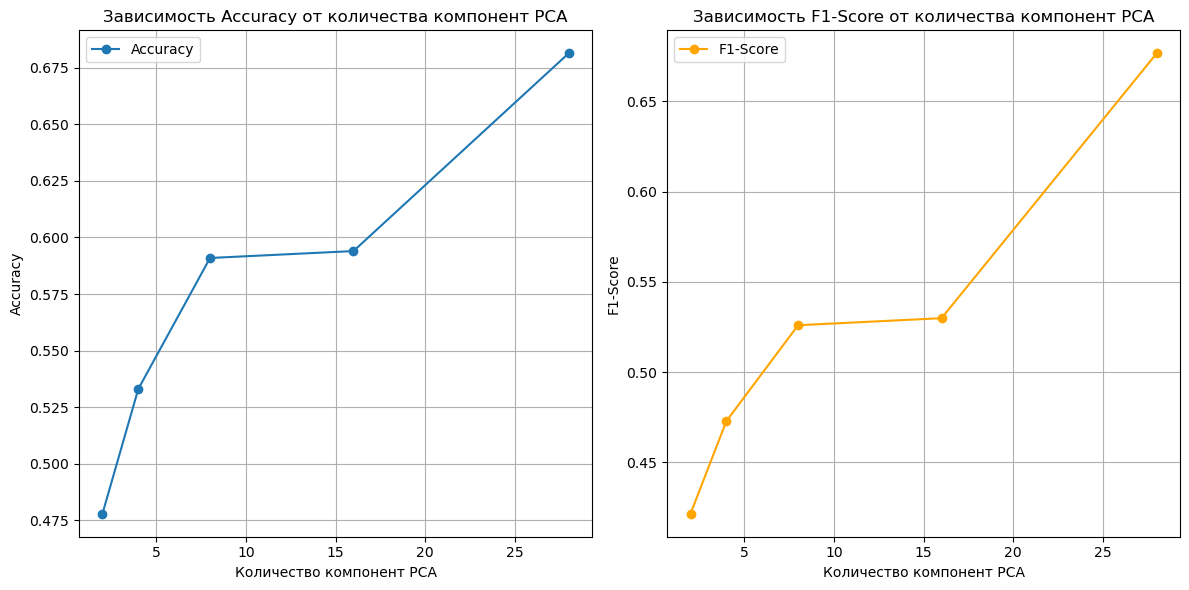

In [194]:
n_components_list = [2, 4, 8, 16, 28]
accuracy_scores = []
f1_scores = []

param_grid = {"C": [0.01, 0.1, 1, 10, 100]}
for n_components in n_components_list:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("logreg", GridSearchCV(
            LogisticRegression(max_iter=500, penalty="l2", random_state=42),
            param_grid={"C": param_grid["C"]},
            cv=5,
            scoring="accuracy"
        ))
    ])
    
    pipeline.fit(X, Y)
    y_pred = pipeline.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")
    accuracy_scores.append(accuracy)
    f1_scores.append(f1)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(n_components_list, accuracy_scores, marker='o', label="Accuracy")
plt.title("Зависимость Accuracy от количества компонент PCA")
plt.xlabel("Количество компонент PCA")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(n_components_list, f1_scores, marker='o', label="F1-Score", color='orange')
plt.title("Зависимость F1-Score от количества компонент PCA")
plt.xlabel("Количество компонент PCA")
plt.ylabel("F1-Score")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()


## t-SNE

**Задание 8.** Обучите t-sne c `n_components=2` на изначальных данных и визуализируйте результаты с учетом известных классов.
P.S. если устанете ждать обучения TSNE, или упадет ошибка по типу oom, то можно сократить число объектов в датасете до, например, пары тысяч.

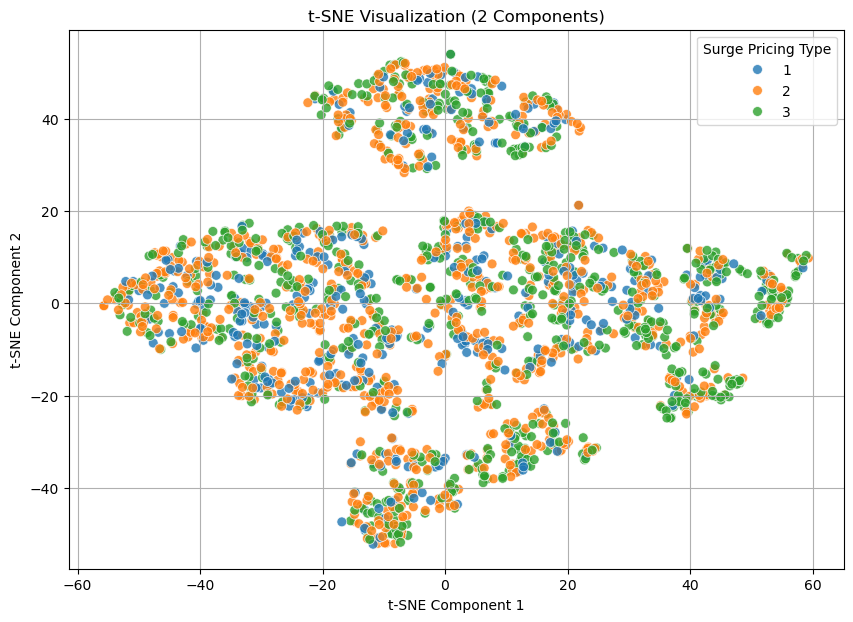

In [235]:
# Ваш код:
sample_size = 2000
data_sampled = data.sample(n=sample_size, random_state=42)
X_sampled = data_encoded_without_id.loc[data_sampled.index]
y_sampled = data.loc[data_sampled.index, "Surge_Pricing_Type"]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_sampled)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y_sampled, palette="tab10", s=50, alpha=0.8
)
plt.title("t-SNE Visualization (2 Components)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend(title="Surge Pricing Type")
plt.grid()
plt.show()